# Clustering Analysis - Phân Cụm Người Dùng

## 1. Import Libraries

In [75]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [76]:
# Thiết lập đường dẫn
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "outputs" / "data_split"/ "cluster_train.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
MODELS_DIR = OUTPUT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load và Tạo User Profiles

In [77]:
# Đọc dữ liệu interactions
df_interactions = pd.read_csv(DATA_PATH)

print(f"📊 Tổng số interactions: {len(df_interactions):,}")
print(f"👥 Số users: {df_interactions['user_idx'].nunique():,}")
df_interactions.head()

📊 Tổng số interactions: 8,328
👥 Số users: 2,958


,user_idx,rating_scaled,year_scaled,genre_count_scaled,genre_action,genre_adventure,genre_animation,genre_comedy,genre_crime,genre_documentary,...,genre_musical,genre_mystery,genre_romance,genre_science_fiction,genre_superhero,genre_suspense,genre_thriller,genre_tv_movie,genre_war,genre_western
0,62,0.888889,0.898990,0.500000,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3462,0.444444,0.989899,0.333333,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,760,0.555556,0.939394,0.500000,1,1,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
3,1768,1.000000,0.949495,0.333333,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,329,0.000000,0.555556,0.000000,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
# Tạo user profiles
print("🔨 Đang tạo user profiles...")
user_profiles = []

for user_id in df_interactions['user_idx'].unique():
    user_data = df_interactions[df_interactions['user_idx'] == user_id]
    
    profile = {
        'user_idx': user_id,
        'avg_rating': user_data['rating_scaled'].mean(),
        'num_ratings': len(user_data),
        'rating_std': user_data['rating_scaled'].std(),
    }
    
    # Tính tỷ lệ xem từng thể loại
    genre_cols = [col for col in user_data.columns if col.startswith('genre_')]
    for genre in genre_cols:
        profile[f'{genre}_pref'] = user_data[genre].mean()
    
    user_profiles.append(profile)

df_user_profiles = pd.DataFrame(user_profiles)
print(f"✅ Đã tạo {len(df_user_profiles)} user profiles")
df_user_profiles.head()

🔨 Đang tạo user profiles...


✅ Đã tạo 2958 user profiles


,user_idx,avg_rating,num_ratings,rating_std,genre_count_scaled_pref,genre_action_pref,genre_adventure_pref,genre_animation_pref,genre_comedy_pref,genre_crime_pref,...,genre_musical_pref,genre_mystery_pref,genre_romance_pref,genre_science_fiction_pref,genre_superhero_pref,genre_suspense_pref,genre_thriller_pref,genre_tv_movie_pref,genre_war_pref,genre_western_pref
0,62,0.608187,57,0.197097,0.315789,0.456140,0.456140,0.105263,0.175439,0.122807,...,0.0,0.070175,0.140351,0.280702,0.0,0.0,0.245614,0.0,0.000000,0.017544
1,3462,0.444444,1,NaN,0.333333,0.000000,1.000000,0.000000,1.000000,1.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
2,760,0.565217,23,0.250506,0.384058,0.347826,0.478261,0.347826,0.478261,0.086957,...,0.0,0.043478,0.086957,0.173913,0.0,0.0,0.217391,0.0,0.000000,0.000000
3,1768,1.000000,1,NaN,0.333333,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
4,329,0.566510,71,0.302345,0.288732,0.295775,0.253521,0.098592,0.380282,0.183099,...,0.0,0.112676,0.098592,0.281690,0.0,0.0,0.154930,0.0,0.042254,0.042254


## 3. Chuẩn Bị Dữ Liệu

In [79]:
# Loại bỏ user_idx và chuẩn bị features
df_features = df_user_profiles.drop('user_idx', axis=1).fillna(0)

print(f"📊 Feature shape: {df_features.shape}")
print(f"   {df_features.shape[0]} users x {df_features.shape[1]} features")

📊 Feature shape: (2958, 28)
   2958 users x 28 features


In [80]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print("✅ Dữ liệu đã được chuẩn hóa")

✅ Dữ liệu đã được chuẩn hóa


## 4. Tìm Số Cụm Tối Ưu

Sử dụng Elbow Method và Silhouette Score để tìm K tối ưu.

In [81]:
# Thử nghiệm với các giá trị K khác nhau
k_range = range(2, 11)
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []
inertias = []

print("🔍 Đang tìm K tối ưu...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    
    print(f"   K={k}: Silhouette={silhouette_scores[-1]:.4f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✅ K tối ưu: {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")

🔍 Đang tìm K tối ưu...
   K=2: Silhouette=0.1921
   K=3: Silhouette=0.1076
   K=4: Silhouette=0.1086
   K=5: Silhouette=0.1298
   K=6: Silhouette=0.1184
   K=7: Silhouette=0.1679
   K=8: Silhouette=0.1653
   K=9: Silhouette=0.1648
   K=10: Silhouette=0.1803

✅ K tối ưu: 2 (Silhouette Score: 0.1921)


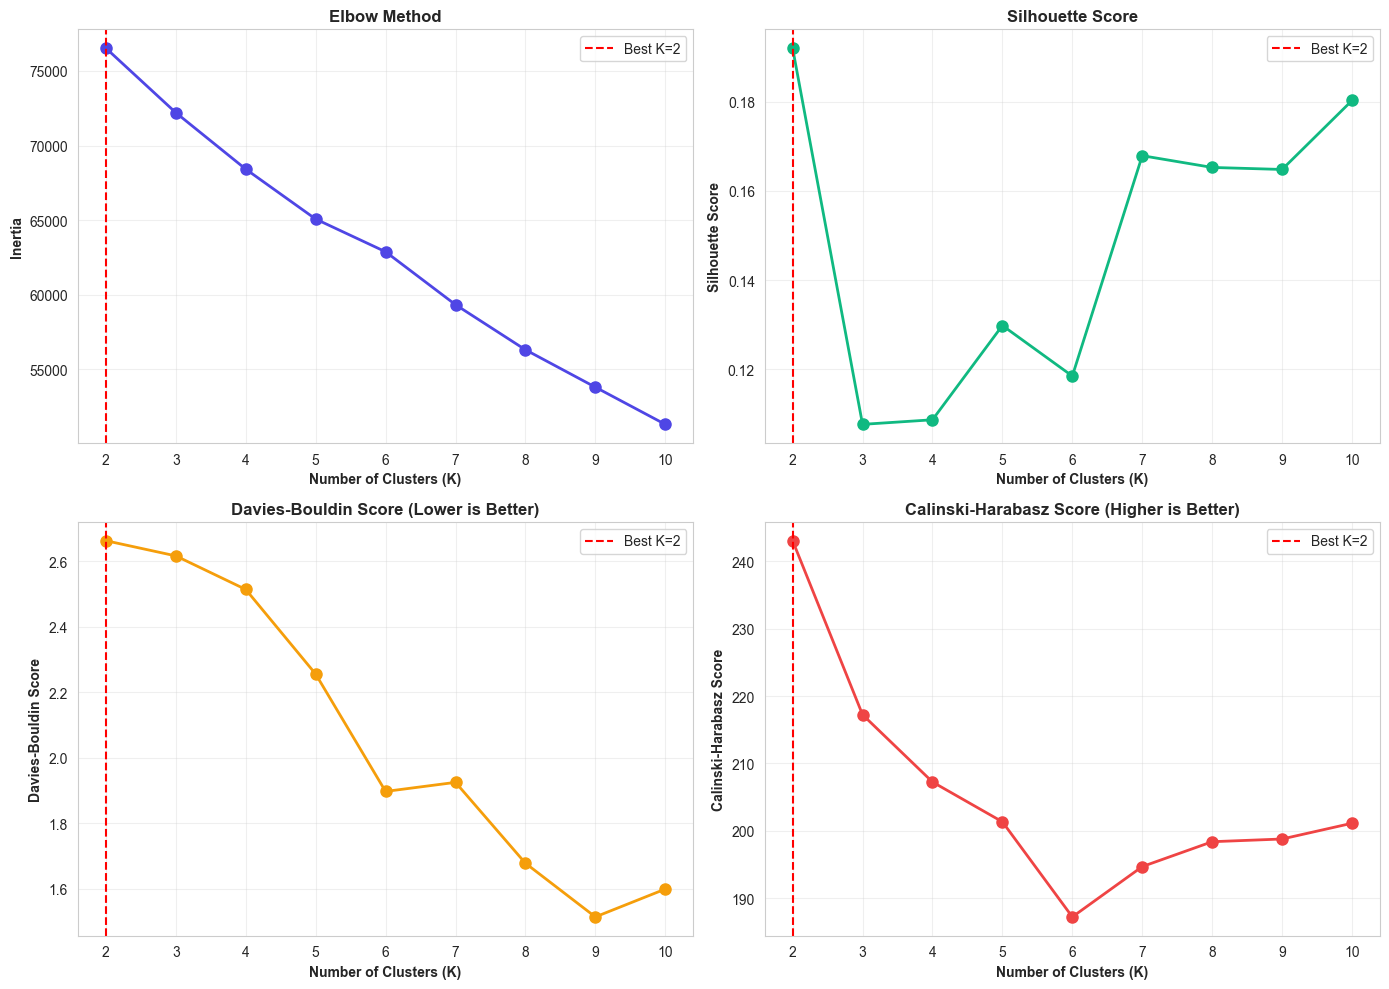

In [82]:
# Visualization: Elbow Method và Silhouette Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Elbow Method
axes[0, 0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='#4f46e5')
axes[0, 0].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[0, 0].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[0, 0].set_ylabel('Inertia', fontweight='bold')
axes[0, 0].set_title('Elbow Method', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Subplot 2: Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#10b981')
axes[0, 1].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[0, 1].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontweight='bold')
axes[0, 1].set_title('Silhouette Score', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Subplot 3: Davies-Bouldin Score (lower is better)
axes[1, 0].plot(k_range, davies_bouldin_scores, marker='o', linewidth=2, markersize=8, color='#f59e0b')
axes[1, 0].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[1, 0].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[1, 0].set_ylabel('Davies-Bouldin Score', fontweight='bold')
axes[1, 0].set_title('Davies-Bouldin Score (Lower is Better)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Subplot 4: Calinski-Harabasz Score (higher is better)
axes[1, 1].plot(k_range, calinski_scores, marker='o', linewidth=2, markersize=8, color='#ef4444')
axes[1, 1].axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[1, 1].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontweight='bold')
axes[1, 1].set_title('Calinski-Harabasz Score (Higher is Better)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clustering_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Thực Hiện Phân Cụm với K Tối Ưu

In [83]:
# Phân cụm với K tối ưu
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans_model.fit_predict(X_scaled)

print(f"✅ Đã phân cụm với K={best_k}")

# Phân phối các cụm
unique, counts = np.unique(labels, return_counts=True)
print(f"\n📊 Phân phối cụm:")
for cid, count in zip(unique, counts):
    print(f"   Cluster {cid}: {count} users ({count/len(labels)*100:.1f}%)")

✅ Đã phân cụm với K=2

📊 Phân phối cụm:
   Cluster 0: 620 users (21.0%)
   Cluster 1: 2338 users (79.0%)


## 6. Đánh Giá Kết Quả

In [84]:
# Tính các metrics
silhouette = silhouette_score(X_scaled, labels)
davies_bouldin = davies_bouldin_score(X_scaled, labels)
calinski = calinski_harabasz_score(X_scaled, labels)

print("📊 Đánh giá chất lượng phân cụm:")
print(f"   Silhouette Score: {silhouette:.4f}")
print(f"   Davies-Bouldin Score: {davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Score: {calinski:.4f}")

if silhouette > 0.5:
    quality = 'Tốt'
elif silhouette > 0.3:
    quality = 'Trung bình'
else:
    quality = 'Yếu'
    
print(f"\n   Chất lượng: {quality}")

📊 Đánh giá chất lượng phân cụm:
   Silhouette Score: 0.1921
   Davies-Bouldin Score: 2.6623
   Calinski-Harabasz Score: 243.0661

   Chất lượng: Yếu


## 7. PCA Visualization

In [85]:
# Giảm chiều xuống 2D bằng PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"📊 PCA Explained Variance:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

📊 PCA Explained Variance:
   PC1: 10.37%
   PC2: 7.87%
   Total: 18.24%


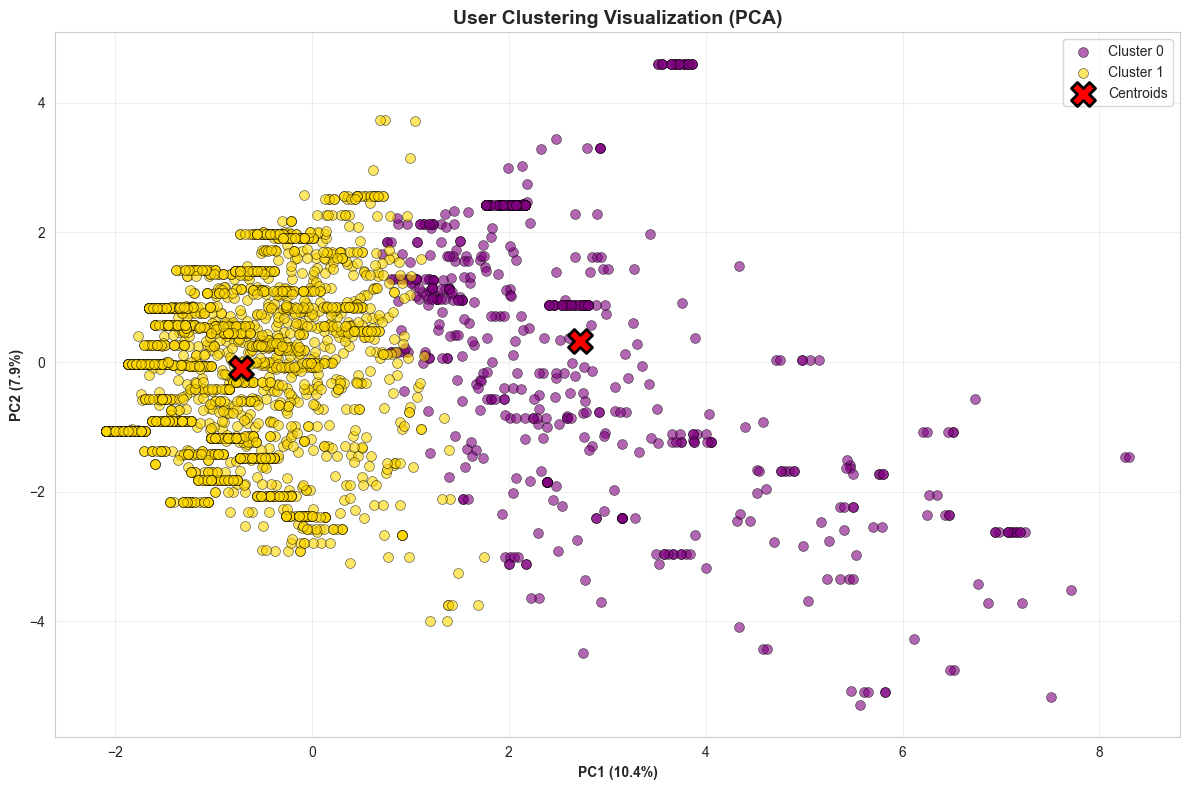

✓ Đã lưu biểu đồ PCA: c:\Users\HP\Downloads\Smart-Movie-Recommender-main\outputs\clustering_pca.png
✓ Đã lưu biểu đồ phân bố: c:\Users\HP\Downloads\Smart-Movie-Recommender-main\outputs\cluster_distribution.png


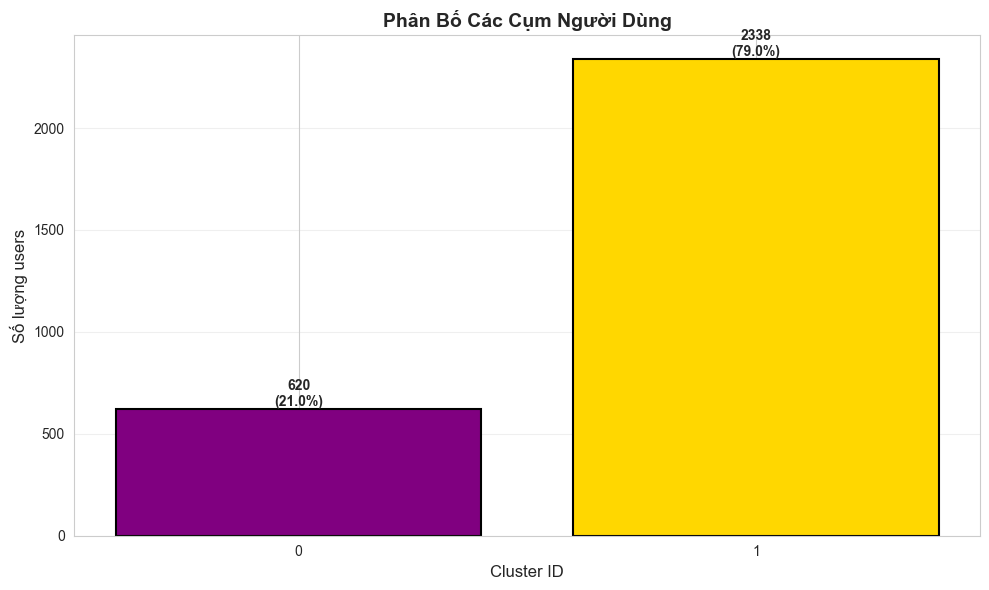

In [86]:
# =========================
# Thiết lập màu sắc thống nhất
# =========================
custom_colors = {
    0: 'purple',   # Cluster 0
    1: 'gold'      # Cluster 1
}

# =========================
# 1. Scatter Plot với PCA
# =========================
plt.figure(figsize=(12, 8))

default_scatter_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    mask = labels == i
    color = custom_colors.get(i, default_scatter_colors[i])

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[color],
        label=f'Cluster {i}',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )

# Vẽ tâm cụm
centroids_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidth=2,
    label='Centroids'
)

plt.xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)',
    fontweight='bold'
)
plt.ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)',
    fontweight='bold'
)
plt.title(
    'User Clustering Visualization (PCA)',
    fontweight='bold',
    fontsize=14
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "clustering_pca.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# =========================
# 2. Biểu đồ phân bố cụm
# =========================
plt.figure(figsize=(10, 6))

unique, counts = np.unique(labels, return_counts=True)

default_bar_colors = plt.cm.viridis(np.linspace(0, 1, len(unique)))
bar_colors = [
    custom_colors.get(cluster_id, default_bar_colors[i])
    for i, cluster_id in enumerate(unique)
]

bars = plt.bar(
    unique,
    counts,
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5
)

plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Số lượng users', fontsize=12)
plt.title('Phân Bố Các Cụm Người Dùng', fontsize=14, fontweight='bold')
plt.xticks(unique)

# Thêm số lượng và tỷ lệ trên mỗi cột
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(count)}\n({count / len(labels) * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / 'cluster_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

print(f"✓ Đã lưu biểu đồ PCA: {OUTPUT_DIR / 'clustering_pca.png'}")
print(f"✓ Đã lưu biểu đồ phân bố: {OUTPUT_DIR / 'cluster_distribution.png'}")

plt.show()

## 8. Phân Tích Đặc Điểm Từng Cụm

In [87]:
# Thêm labels vào user profiles
df_with_clusters = df_user_profiles.copy()
df_with_clusters['user_cluster'] = labels

# Phân tích từng cụm
cluster_profiles = []

for cluster_id in range(best_k):
    cluster_data = df_with_clusters[df_with_clusters['user_cluster'] == cluster_id]
    
    profile = {
        'cluster_id': cluster_id,
        'num_users': len(cluster_data),
        'percentage': len(cluster_data) / len(df_user_profiles) * 100,
        'avg_rating': cluster_data['avg_rating'].mean(),
        'avg_num_ratings': cluster_data['num_ratings'].mean(),
        'avg_rating_std': cluster_data['rating_std'].mean()
    }
    
    # Top 5 thể loại
    genre_pref_cols = [col for col in cluster_data.columns if col.endswith('_pref')]
    if genre_pref_cols:
        genre_means = cluster_data[genre_pref_cols].mean().sort_values(ascending=False)
        top_5_genres = genre_means.head(5)
        
        profile['top_genres'] = []
        for genre, score in top_5_genres.items():
            genre_name = genre.replace('genre_', '').replace('_pref', '')
            profile['top_genres'].append({
                'genre': genre_name,
                'preference_score': float(score)
            })
    
    cluster_profiles.append(profile)

# Hiển thị cluster profiles
profiles_df = pd.DataFrame(cluster_profiles)
print("📊 Cluster Profiles:")
profiles_df

📊 Cluster Profiles:


,cluster_id,num_users,percentage,avg_rating,avg_num_ratings,avg_rating_std,top_genres
0,0,620,20.960108,0.610086,5.330645,0.180762,"[{'genre': 'adventure', 'preference_score': 0...."
1,1,2338,79.039892,0.505290,2.148417,0.176138,"[{'genre': 'thriller', 'preference_score': 0.3..."


In [88]:
# Hiển thị chi tiết từng cụm
for profile in cluster_profiles:
    print(f"\n{'='*60}")
    print(f"🎯 CLUSTER {profile['cluster_id']}")
    print(f"{'='*60}")
    print(f"   Số users: {profile['num_users']} ({profile['percentage']:.1f}%)")
    print(f"   Avg rating: {profile['avg_rating']:.2f}")
    print(f"   Avg num ratings: {profile['avg_num_ratings']:.1f}")
    print(f"   Avg rating std: {profile['avg_rating_std']:.2f}")
    print(f"\n   Top 5 Genres:")
    for i, genre_info in enumerate(profile['top_genres'], 1):
        print(f"      {i}. {genre_info['genre']}: {genre_info['preference_score']:.3f}")


🎯 CLUSTER 0
   Số users: 620 (21.0%)
   Avg rating: 0.61
   Avg num ratings: 5.3
   Avg rating std: 0.18

   Top 5 Genres:
      1. adventure: 0.663
      2. action: 0.523
      3. science_fiction: 0.458
      4. count_scaled: 0.388
      5. comedy: 0.325

🎯 CLUSTER 1
   Số users: 2338 (79.0%)
   Avg rating: 0.51
   Avg num ratings: 2.1
   Avg rating std: 0.18

   Top 5 Genres:
      1. thriller: 0.365
      2. drama: 0.312
      3. horror: 0.271
      4. comedy: 0.242
      5. action: 0.201


## 9. Lưu Kết Quả

In [89]:
# Lưu cluster profiles (Parquet)
profiles_save = profiles_df.copy()
if 'top_genres' in profiles_save.columns:
    profiles_save['top_genres'] = profiles_save['top_genres'].apply(json.dumps)

profiles_save.to_parquet(OUTPUT_DIR / 'user_cluster_profiles.parquet', engine='pyarrow', index=False)
print("✅ Đã lưu user_cluster_profiles.parquet")

ImportError: Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.

In [ ]:
# Lưu users với labels (Parquet)
df_with_clusters.to_parquet(OUTPUT_DIR / 'users_clustered.parquet', engine='pyarrow', index=False)
print("✅ Đã lưu users_clustered.parquet")

In [ ]:
# Lưu models
joblib.dump(kmeans_model, MODELS_DIR / 'kmeans_users.pkl')
joblib.dump(scaler, MODELS_DIR / 'user_clustering_scaler.pkl')
joblib.dump(pca, MODELS_DIR / 'user_clustering_pca.pkl')
print("✅ Đã lưu models")

In [ ]:
# Lưu metrics
metrics = {
    'num_users': len(df_user_profiles),
    'num_features': df_features.shape[1],
    'k_analysis': {
        'k_values': list(k_range),
        'inertias': inertias,
        'silhouette_scores': silhouette_scores,
        'davies_bouldin_scores': davies_bouldin_scores,
        'calinski_harabasz_scores': calinski_scores,
        'best_k': best_k,
        'best_silhouette': max(silhouette_scores)
    },
    'cluster_distribution': {f'cluster_{int(cid)}': int(count) for cid, count in zip(unique, counts)},
    'cluster_percentages': {f'cluster_{int(cid)}': float(count / len(labels) * 100) for cid, count in zip(unique, counts)},
    'silhouette_score': float(silhouette),
    'davies_bouldin_score': float(davies_bouldin),
    'calinski_harabasz_score': float(calinski),
    'quality': quality,
    'pca': {
        'n_components': 2,
        'explained_variance_ratio': pca.explained_variance_ratio_.tolist(),
        'total_explained_variance': float(sum(pca.explained_variance_ratio_))
    },
    'cluster_profiles': cluster_profiles
}

with open(OUTPUT_DIR / 'clustering_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("✅ Đã lưu clustering_metrics.json")

## 10. Tổng Kết

Quá trình phân cụm người dùng đã hoàn thành:

- **Thuật toán**: K-Means
- **Số cụm tối ưu**: {best_k}
- **Silhouette Score**: {silhouette:.4f}
- **Chất lượng**: {quality}
- **Outputs**: user_cluster_profiles.parquet, users_clustered.parquet, models, clustering_metrics.json